In [1]:
import sys
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

ROOT = Path(".")
DATA_PATH = ROOT / "S12-hw-dataset.csv"

ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_GRU_PATH = ARTIFACTS_DIR / "best_gru.pt"
BEST_GRU_CONFIG_PATH = ARTIFACTS_DIR / "best_gru_config.json"

SERIES_SPLIT_FIG_PATH = FIGURES_DIR / "series_split.png"
BASELINES_COMPARE_FIG_PATH = FIGURES_DIR / "baselines_compare.png"
GRU_CURVES_FIG_PATH = FIGURES_DIR / "gru_learning_curves.png"
BEST_FORECAST_TEST_FIG_PATH = FIGURES_DIR / "best_forecast_test.png"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch:", torch.__version__)
print("Device:", DEVICE)
print("Seed:", SEED)
print("Data path:", DATA_PATH)

Python: 3.13.11
pandas: 2.3.3
numpy: 2.3.4
scikit-learn: 1.7.2
torch: 2.11.0+cu130
Device: cuda
Seed: 42
Data path: S12-hw-dataset.csv


Почему random split некорректен для временного ряда:
1) наблюдения зависят от прошлого и должны идти в естественном временном порядке;
2) random split перемешивает прошлое и будущее, из-за чего в train могут попасть наблюдения позже validation/test;
3) это приводит к утечке информации и завышенной оценке качества;
4) поэтому для time series нужен только temporal split: train -> validation -> test.

In [2]:
DATASET_NAME = "S12-hw-dataset.csv"
TASK_NAME = "time_series_forecasting"
TARGET_COLUMN = "target"
FREQUENCY = "1H"
HORIZON = 1

EXPERIMENTS = {
    "B1": "naive-last",
    "B2": "moving-average-24",
    "B3": "ridge-lag-features",
    "R1": "gru-forecast",
}

print("Experiments:", EXPERIMENTS)

Experiments: {'B1': 'naive-last', 'B2': 'moving-average-24', 'B3': 'ridge-lag-features', 'R1': 'gru-forecast'}


In [3]:
NOTEBOOK_RELATIVE_ARTIFACT_PATHS = {
    "runs_csv": "./artifacts/runs.csv",
    "best_gru_pt": "./artifacts/best_gru.pt",
    "best_gru_config_json": "./artifacts/best_gru_config.json",
    "series_split_png": "./artifacts/figures/series_split.png",
    "baselines_compare_png": "./artifacts/figures/baselines_compare.png",
    "gru_learning_curves_png": "./artifacts/figures/gru_learning_curves.png",
    "best_forecast_test_png": "./artifacts/figures/best_forecast_test.png",
}

print(json.dumps(NOTEBOOK_RELATIVE_ARTIFACT_PATHS, indent=2, ensure_ascii=False))

{
  "runs_csv": "./artifacts/runs.csv",
  "best_gru_pt": "./artifacts/best_gru.pt",
  "best_gru_config_json": "./artifacts/best_gru_config.json",
  "series_split_png": "./artifacts/figures/series_split.png",
  "baselines_compare_png": "./artifacts/figures/baselines_compare.png",
  "gru_learning_curves_png": "./artifacts/figures/gru_learning_curves.png",
  "best_forecast_test_png": "./artifacts/figures/best_forecast_test.png"
}


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

assert {"date", "target"} <= set(df.columns), "Ожидаются колонкижидаются колонки: date, target"

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print(df.head())
print()
print(df.tail())

Shape: (4320, 2)
Columns: ['date', 'target']

                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

                    date  target
4315 2025-06-29 19:00:00  153.05
4316 2025-06-29 20:00:00  134.23
4317 2025-06-29 21:00:00  137.68
4318 2025-06-29 22:00:00  126.53
4319 2025-06-29 23:00:00  120.89


In [5]:
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="H")
missing_timestamps = full_range.difference(pd.DatetimeIndex(df["date"]))
duplicate_dates = int(df["date"].duplicated().sum())
missing_target = int(df["target"].isna().sum())
inferred_freq = pd.infer_freq(df["date"])

print("Date min:", df["date"].min())
print("Date max:", df["date"].max())
print("Inferred freq:", inferred_freq)
print("Expected length from full hourly range:", len(full_range))
print("Actual length:", len(df))
print("Missing timestamps:", len(missing_timestamps))
print("Duplicate timestamps:", duplicate_dates)
print("Missing target values:", missing_target)
print()
print(df["target"].describe())

Date min: 2025-01-01 00:00:00
Date max: 2025-06-29 23:00:00
Inferred freq: h
Expected length from full hourly range: 4320
Actual length: 4320
Missing timestamps: 0
Duplicate timestamps: 0
Missing target values: 0

count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


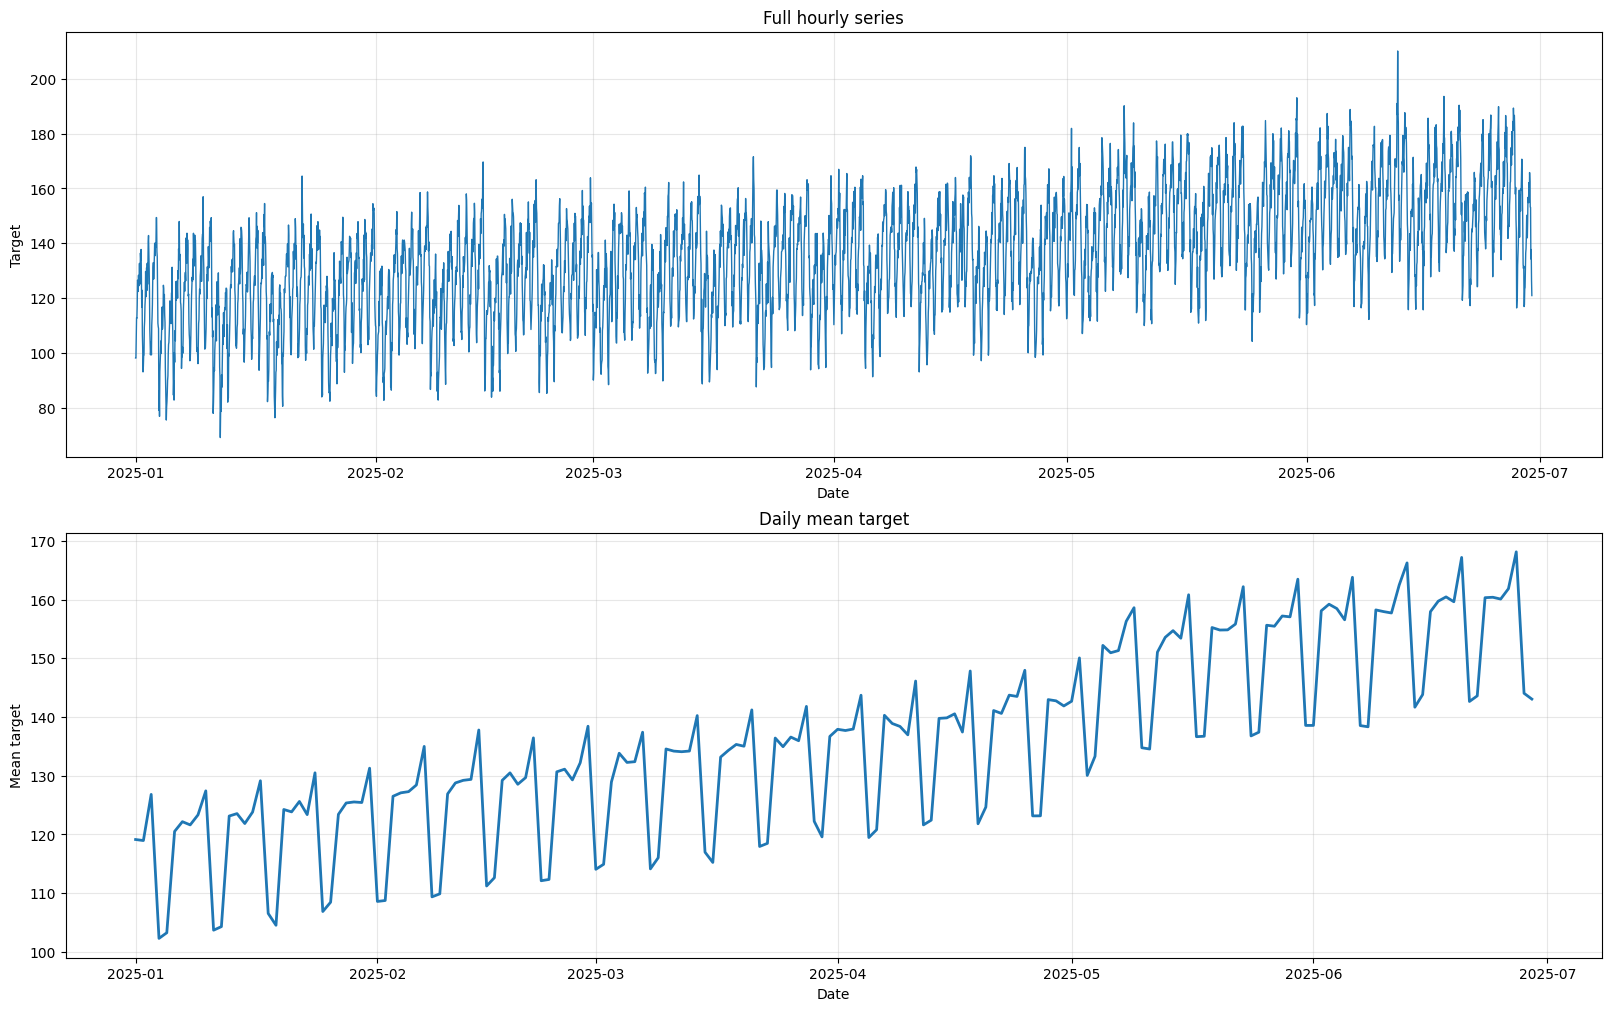

In [6]:
df["date_only"] = df["date"].dt.date
daily_mean = df.groupby("date_only", as_index=False)["target"].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

axes[0].plot(df["date"], df["target"], linewidth=1.0)
axes[0].set_title("Full hourly series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Target")
axes[0].grid(alpha=0.3)

axes[1].plot(pd.to_datetime(daily_mean["date_only"]), daily_mean["target"], linewidth=2.0)
axes[1].set_title("Daily mean target")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mean target")
axes[1].grid(alpha=0.3)

plt.show()

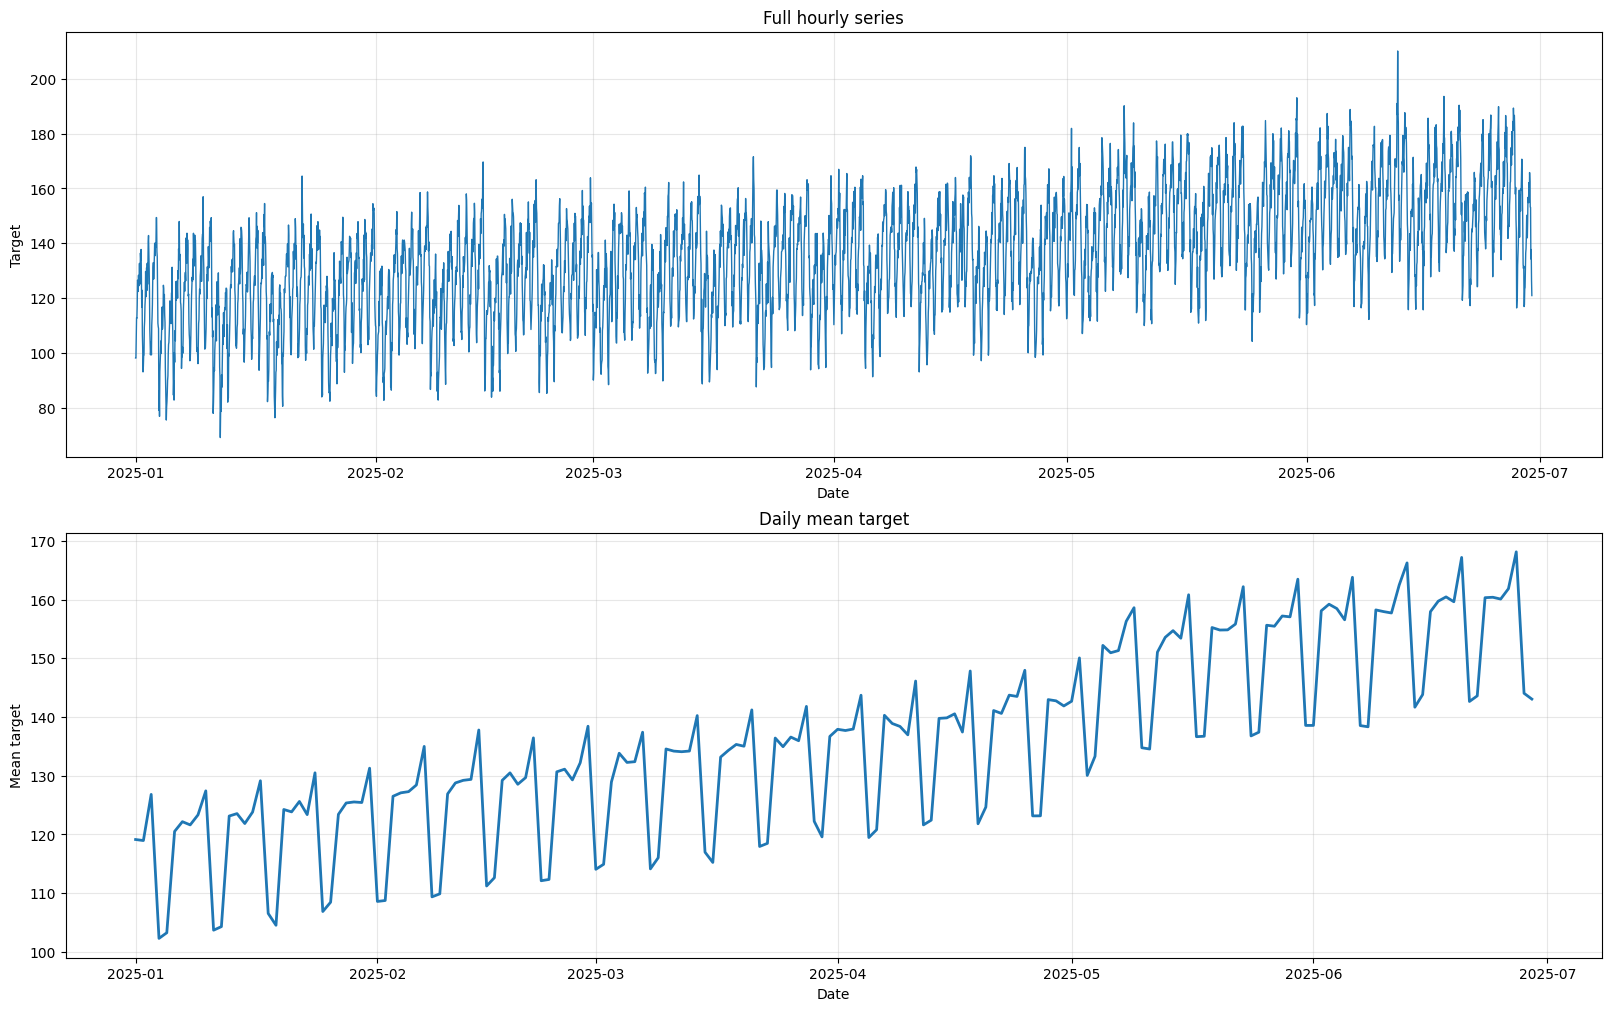

In [7]:
df["date_only"] = df["date"].dt.date
daily_mean = df.groupby("date_only", as_index=False)["target"].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

axes[0].plot(df["date"], df["target"], linewidth=1.0)
axes[0].set_title("Full hourly series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Target")
axes[0].grid(alpha=0.3)

axes[1].plot(pd.to_datetime(daily_mean["date_only"]), daily_mean["target"], linewidth=2.0)
axes[1].set_title("Daily mean target")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mean target")
axes[1].grid(alpha=0.3)

plt.show()

{
  "strategy": "temporal_split",
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "train_start": "2025-01-01 00:00:00",
  "train_end": "2025-05-06 23:00:00",
  "validation_start": "2025-05-07 00:00:00",
  "validation_end": "2025-06-02 23:00:00",
  "test_start": "2025-06-03 00:00:00",
  "test_end": "2025-06-29 23:00:00",
  "random_split_used": false,
  "shuffle_used_for_temporal_folds": false,
  "reason_random_split_incorrect": "random split mixes past and future observations and can leak future information into training"
}


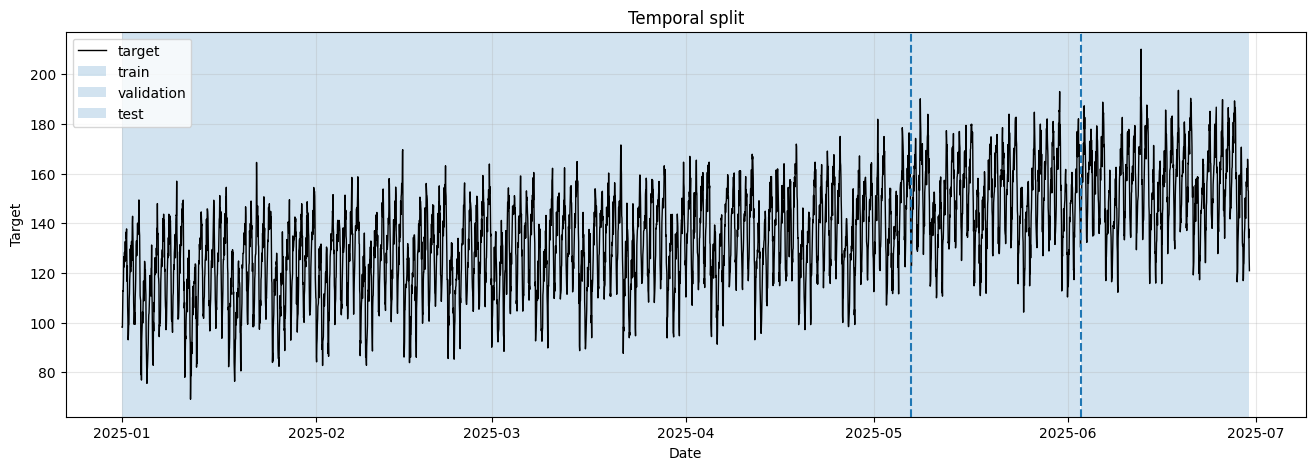

Saved: ./artifacts/figures/series_split.png


In [8]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

TRAIN_START_TS = df.loc[0, "date"]
TRAIN_END_TS = df.loc[train_end - 1, "date"]

VAL_START_TS = df.loc[train_end, "date"]
VAL_END_TS = df.loc[val_end - 1, "date"]

TEST_START_TS = df.loc[val_end, "date"]
TEST_END_TS = df.loc[n - 1, "date"]

SPLIT_SUMMARY_STRUCT = {
    "strategy": "temporal_split",
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,
    "train_start": str(TRAIN_START_TS),
    "train_end": str(TRAIN_END_TS),
    "validation_start": str(VAL_START_TS),
    "validation_end": str(VAL_END_TS),
    "test_start": str(TEST_START_TS),
    "test_end": str(TEST_END_TS),
    "random_split_used": False,
    "shuffle_used_for_temporal_folds": False,
    "reason_random_split_incorrect": (
        "random split mixes past and future observations and can leak future information into training"
    ),
}

print(json.dumps(SPLIT_SUMMARY_STRUCT, indent=2, ensure_ascii=False))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["target"], linewidth=1.0, color="black", label="target")

ax.axvspan(TRAIN_START_TS, TRAIN_END_TS, alpha=0.20, label="train")
ax.axvspan(VAL_START_TS, VAL_END_TS, alpha=0.20, label="validation")
ax.axvspan(TEST_START_TS, TEST_END_TS, alpha=0.20, label="test")

ax.axvline(VAL_START_TS, linestyle="--", linewidth=1.5)
ax.axvline(TEST_START_TS, linestyle="--", linewidth=1.5)

ax.set_title("Temporal split")
ax.set_xlabel("Date")
ax.set_ylabel("Target")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(SERIES_SPLIT_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["series_split_png"])

In [9]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics(y_true, y_pred) -> dict:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
    }

def evaluate_predictions(frame: pd.DataFrame, y_col: str, pred_col: str) -> dict:
    tmp = frame[[y_col, pred_col]].dropna().copy()
    metrics = regression_metrics(tmp[y_col], tmp[pred_col])
    return metrics

In [10]:
results_rows = []
test_prediction_frames = {}

df_baselines = df[["date", "target"]].copy()

df_baselines["pred_b1_naive_last"] = df_baselines["target"].shift(1)
df_baselines["pred_b2_moving_average_24"] = (
    df_baselines["target"].shift(1).rolling(24).mean()
)

val_slice = slice(train_end, val_end)
test_slice = slice(val_end, len(df_baselines))

baseline_map = {
    "B1_naive_last": "pred_b1_naive_last",
    "B2_moving_average_24": "pred_b2_moving_average_24",
}

for run_name, pred_col in baseline_map.items():
    val_frame = df_baselines.iloc[val_slice][["date", "target", pred_col]].dropna().copy()
    test_frame = df_baselines.iloc[test_slice][["date", "target", pred_col]].dropna().copy()

    val_metrics = regression_metrics(val_frame["target"], val_frame[pred_col])
    test_metrics = regression_metrics(test_frame["target"], test_frame[pred_col])

    results_rows.append(
        {
            "run_name": run_name,
            "model_family": "baseline",
            "window_size": None,
            "alpha": None,
            "hidden_size": None,
            "num_layers": None,
            "dropout": None,
            "batch_size": None,
            "max_epochs": None,
            "learning_rate": None,
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "val_mape": val_metrics["mape"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_mape": test_metrics["mape"],
        }
    )

    test_prediction_frames[run_name] = pd.DataFrame(
        {
            "date": test_frame["date"].values,
            "actual": test_frame["target"].values,
            "prediction": test_frame[pred_col].values,
        }
    )

baseline_results_df = pd.DataFrame(results_rows)
display(baseline_results_df)

,run_name,model_family,window_size,alpha,hidden_size,num_layers,dropout,batch_size,max_epochs,learning_rate,val_mae,val_rmse,val_mape,test_mae,test_rmse,test_mape
0,B1_naive_last,baseline,None,None,None,None,None,None,None,None,6.444815,8.201023,4.397922,6.342438,8.059069,4.148548
1,B2_moving_average_24,baseline,None,None,None,None,None,None,None,None,13.397980,16.169904,9.198834,13.140498,16.110844,8.738701


In [11]:
def make_tabular_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data[["date", "target"]].copy()

    out["hour"] = out["date"].dt.hour
    out["day_of_week"] = out["date"].dt.dayofweek
    out["day_of_month"] = out["date"].dt.day
    out["month"] = out["date"].dt.month
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

    out["trend_idx"] = np.arange(len(out))

    out["lag_1"]  = out["target"].shift(1)
    out["lag_7"]  = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)

    shifted_target = out["target"].shift(1)
    out["rolling_min_7"] = shifted_target.rolling(7).min()
    out["rolling_max_7"] = shifted_target.rolling(7).max()
    out["rolling_mean_7"] = shifted_target.rolling(7).mean()
    out["rolling_std_7"] = shifted_target.rolling(7).std()

    for lag in [2, 3, 24, 25, 48, 72, 168]:
        out[f"lag_{lag}"] = out["target"].shift(lag)


    for window in [24, 168]:
        out[f"rolling_mean_{window}"] = shifted_target.rolling(window).mean()
        out[f"rolling_std_{window}"] = shifted_target.rolling(window).std()
        out[f"rolling_min_{window}"]  = shifted_target.rolling(window).min()
        out[f"rolling_max_{window}"]  = shifted_target.rolling(window).max()

    return out

feature_df = make_tabular_features(df).dropna().reset_index(drop=True)

train_mask = feature_df["date"] <= TRAIN_END_TS
val_mask = (feature_df["date"] >= VAL_START_TS) & (feature_df["date"] <= VAL_END_TS)
test_mask = feature_df["date"] >= TEST_START_TS

feature_cols = [c for c in feature_df.columns if c not in ["date", "target"]]

FEATURES_SUMMARY_TEXT = (
    "lags=[1,2,3,7,14,24,25,48,72,168]; "
    "rolling=[mean,std,min,max] for windows [7,24,168]; "
    "calendar=[hour,day_of_week,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos]; "
    "trend=[trend_idx]"
)

X_train = feature_df.loc[train_mask, feature_cols].copy()
y_train = feature_df.loc[train_mask, "target"].copy()

X_val = feature_df.loc[val_mask, feature_cols].copy()
y_val = feature_df.loc[val_mask, "target"].copy()

X_test = feature_df.loc[test_mask, feature_cols].copy()
y_test = feature_df.loc[test_mask, "target"].copy()

print("Number of features:", len(feature_cols))
print("Train feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Test feature shape:", X_test.shape)
print("Features summary:", FEATURES_SUMMARY_TEXT)

Number of features: 32
Train feature shape: (2856, 32)
Validation feature shape: (648, 32)
Test feature shape: (648, 32)
Features summary: lags=[1,2,3,7,14,24,25,48,72,168]; rolling=[mean,std,min,max] for windows [7,24,168]; calendar=[hour,day_of_week,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos]; trend=[trend_idx]


In [12]:
ridge_candidates = [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]

ridge_scaler = StandardScaler()
X_train_scaled = ridge_scaler.fit_transform(X_train)
X_val_scaled = ridge_scaler.transform(X_val)
X_test_scaled = ridge_scaler.transform(X_test)

best_ridge_model = None
best_ridge_alpha = None
best_ridge_val_mae = float("inf")
best_ridge_val_pred = None
best_ridge_test_pred = None

for alpha in ridge_candidates:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    val_pred = model.predict(X_val_scaled)
    test_pred = model.predict(X_test_scaled)

    val_metrics = regression_metrics(y_val, val_pred)

    if val_metrics["mae"] < best_ridge_val_mae:
        best_ridge_val_mae = val_metrics["mae"]
        best_ridge_model = model
        best_ridge_alpha = alpha
        best_ridge_val_pred = val_pred.copy()
        best_ridge_test_pred = test_pred.copy()

ridge_val_metrics = regression_metrics(y_val, best_ridge_val_pred)
ridge_test_metrics = regression_metrics(y_test, best_ridge_test_pred)

results_rows.append(
    {
        "run_name": "B3_ridge_lag_features",
        "model_family": "ridge_tabular",
        "window_size": None,
        "alpha": best_ridge_alpha,
        "hidden_size": None,
        "num_layers": None,
        "dropout": None,
        "batch_size": None,
        "max_epochs": None,
        "learning_rate": None,
        "val_mae": ridge_val_metrics["mae"],
        "val_rmse": ridge_val_metrics["rmse"],
        "val_mape": ridge_val_metrics["mape"],
        "test_mae": ridge_test_metrics["mae"],
        "test_rmse": ridge_test_metrics["rmse"],
        "test_mape": ridge_test_metrics["mape"],
    }
)

test_prediction_frames["B3_ridge_lag_features"] = pd.DataFrame(
    {
        "date": feature_df.loc[test_mask, "date"].values,
        "actual": y_test.values,
        "prediction": best_ridge_test_pred,
    }
)

RIDGE_SCALER_SUMMARY = "StandardScaler(train_only_fit_then_val_test_transform)"
print("Best Ridge alpha:", best_ridge_alpha)
print("Validation metrics:", ridge_val_metrics)
print("Test metrics:", ridge_test_metrics)
print("Scaler:", RIDGE_SCALER_SUMMARY)

Best Ridge alpha: 30.0
Validation metrics: {'mae': 4.082912827976919, 'rmse': 5.29952045569188, 'mape': 2.7377026058359806}
Test metrics: {'mae': 3.8560556448930723, 'rmse': 5.1021854436974, 'mape': 2.4970604437018937}
Scaler: StandardScaler(train_only_fit_then_val_test_transform)


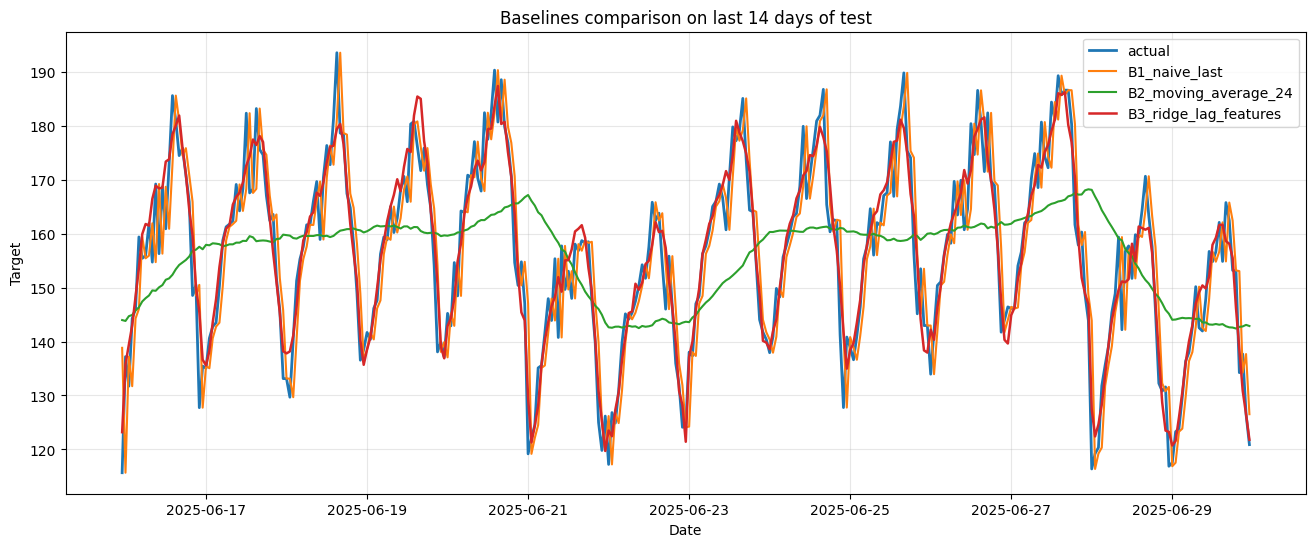

Saved: ./artifacts/figures/baselines_compare.png


In [13]:
plot_df = test_prediction_frames["B3_ridge_lag_features"][["date", "actual"]].copy()
plot_df = plot_df.rename(columns={"actual": "actual"})

plot_df = plot_df.merge(
    test_prediction_frames["B1_naive_last"][["date", "prediction"]].rename(columns={"prediction": "B1_naive_last"}),
    on="date",
    how="left",
)

plot_df = plot_df.merge(
    test_prediction_frames["B2_moving_average_24"][["date", "prediction"]].rename(columns={"prediction": "B2_moving_average_24"}),
    on="date",
    how="left",
)

plot_df = plot_df.merge(
    test_prediction_frames["B3_ridge_lag_features"][["date", "prediction"]].rename(columns={"prediction": "B3_ridge_lag_features"}),
    on="date",
    how="left",
)

plot_cutoff = plot_df["date"].max() - pd.Timedelta(days=14)
plot_tail = plot_df.loc[plot_df["date"] >= plot_cutoff].copy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(plot_tail["date"], plot_tail["actual"], linewidth=2.0, label="actual")
ax.plot(plot_tail["date"], plot_tail["B1_naive_last"], linewidth=1.5, label="B1_naive_last")
ax.plot(plot_tail["date"], plot_tail["B2_moving_average_24"], linewidth=1.5, label="B2_moving_average_24")
ax.plot(plot_tail["date"], plot_tail["B3_ridge_lag_features"], linewidth=1.8, label="B3_ridge_lag_features")

ax.set_title("Baselines comparison on last 14 days of test")
ax.set_xlabel("Date")
ax.set_ylabel("Target")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(BASELINES_COMPARE_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["baselines_compare_png"])

In [14]:
train_target_values = df.loc[: train_end - 1, "target"].to_numpy(dtype=np.float32)
target_mean = float(train_target_values.mean())
target_std = float(train_target_values.std())

full_target = df["target"].to_numpy(dtype=np.float32)
full_target_scaled = ((full_target - target_mean) / target_std).astype(np.float32)

GRU_CONFIG = {
    "experiment_id": "R1_gru_forecast_seed42_ws168",
    "task": TASK_NAME,
    "dataset": DATASET_NAME,
    "seed": SEED,
    "target_column": TARGET_COLUMN,
    "frequency": FREQUENCY,
    "horizon": HORIZON,
    "window_size": 168,
    "input_size": 1,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "batch_size": 128,
    "max_epochs": 20,
    "patience": 5,
    "learning_rate": 1e-3,
    "grad_clip": 1.0,
    "architecture": {
        "model_type": "GRUForecast",
        "rnn_type": "GRU",
        "input_size": 1,
        "hidden_size": 32,
        "num_layers": 1,
        "dropout": 0.0,
        "head": "Linear(hidden_size -> 1)",
    },
    "training_hyperparameters": {
        "loss": "MSELoss",
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "batch_size": 128,
        "max_epochs": 20,
        "patience": 5,
        "grad_clip": 1.0,
        "model_selection_metric": "val_mae",
    },
    "scaler": {
        "name": "zscore_train_only",
        "fit_on": "train_only",
        "target_mean": target_mean,
        "target_std": target_std,
        "formula": "(x - train_mean) / train_std",
    },
}

def make_sequence_data(series_scaled: np.ndarray, target_indices: np.ndarray, window_size: int):
    X, y, target_dates = [], [], []

    for idx in target_indices:
        left = idx - window_size
        if left < 0:
            continue
        X.append(series_scaled[left:idx])
        y.append(series_scaled[idx])
        target_dates.append(df.loc[idx, "date"])

    X = np.asarray(X, dtype=np.float32)[:, :, None]
    y = np.asarray(y, dtype=np.float32)[:, None]
    target_dates = np.asarray(target_dates)

    return X, y, target_dates

train_target_indices = np.arange(GRU_CONFIG["window_size"], train_end)
val_target_indices = np.arange(train_end, val_end)
test_target_indices = np.arange(val_end, len(df))

X_train_seq, y_train_seq, train_seq_dates = make_sequence_data(
    full_target_scaled, train_target_indices, GRU_CONFIG["window_size"]
)
X_val_seq, y_val_seq, val_seq_dates = make_sequence_data(
    full_target_scaled, val_target_indices, GRU_CONFIG["window_size"]
)
X_test_seq, y_test_seq, test_seq_dates = make_sequence_data(
    full_target_scaled, test_target_indices, GRU_CONFIG["window_size"]
)

print(json.dumps(GRU_CONFIG, indent=2, ensure_ascii=False))
print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Validation sequences:", X_val_seq.shape, y_val_seq.shape)
print("Test sequences:", X_test_seq.shape, y_test_seq.shape)

{
  "experiment_id": "R1_gru_forecast_seed42_ws168",
  "task": "time_series_forecasting",
  "dataset": "S12-hw-dataset.csv",
  "seed": 42,
  "target_column": "target",
  "frequency": "1H",
  "horizon": 1,
  "window_size": 168,
  "input_size": 1,
  "hidden_size": 32,
  "num_layers": 1,
  "dropout": 0.0,
  "batch_size": 128,
  "max_epochs": 20,
  "patience": 5,
  "learning_rate": 0.001,
  "grad_clip": 1.0,
  "architecture": {
    "model_type": "GRUForecast",
    "rnn_type": "GRU",
    "input_size": 1,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "head": "Linear(hidden_size -> 1)"
  },
  "training_hyperparameters": {
    "loss": "MSELoss",
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 128,
    "max_epochs": 20,
    "patience": 5,
    "grad_clip": 1.0,
    "model_selection_metric": "val_mae"
  },
  "scaler": {
    "name": "zscore_train_only",
    "fit_on": "train_only",
    "target_mean": 128.2057647705078,
    "target_std": 18.48154258728027

In [15]:
class SequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


class GRUForecast(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 32, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, hidden = self.gru(x)
        last_hidden = hidden[-1]
        out = self.head(last_hidden)
        return out


def inverse_scale(arr: np.ndarray, mean_: float, std_: float) -> np.ndarray:
    return arr * std_ + mean_


def evaluate_torch_model(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    target_mean_: float,
    target_std_: float,
    loss_fn: nn.Module | None = None,
) -> dict:
    model.eval()

    all_preds_scaled = []
    all_targets_scaled = []
    batch_losses = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)

            if loss_fn is not None:
                loss = loss_fn(preds, yb)
                batch_losses.append(float(loss.item()))

            all_preds_scaled.append(preds.detach().cpu().numpy())
            all_targets_scaled.append(yb.detach().cpu().numpy())

    preds_scaled = np.vstack(all_preds_scaled).reshape(-1)
    targets_scaled = np.vstack(all_targets_scaled).reshape(-1)

    preds = inverse_scale(preds_scaled, target_mean_, target_std_)
    targets = inverse_scale(targets_scaled, target_mean_, target_std_)

    out = regression_metrics(targets, preds)
    out["predictions"] = preds
    out["targets"] = targets
    out["scaled_predictions"] = preds_scaled
    out["scaled_targets"] = targets_scaled
    out["loss"] = float(np.mean(batch_losses)) if batch_losses else None

    return out


def train_gru_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: dict,
    device: torch.device,
    target_mean_: float,
    target_std_: float,
):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": [],
    }

    best_state = None
    best_epoch = None
    best_val_mae = float("inf")
    patience_left = config["patience"]

    for epoch in range(1, config["max_epochs"] + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config["grad_clip"])
            optimizer.step()

            train_losses.append(float(loss.item()))

        val_eval = evaluate_torch_model(
            model=model,
            loader=val_loader,
            device=device,
            target_mean_=target_mean_,
            target_std_=target_std_,
            loss_fn=loss_fn,
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_eval["loss"])
        history["val_mae"].append(val_eval["mae"])
        history["val_rmse"].append(val_eval["rmse"])
        history["val_mape"].append(val_eval["mape"])

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={history['train_loss'][-1]:.6f} | "
            f"val_loss={history['val_loss'][-1]:.6f} | "
            f"val_mae={history['val_mae'][-1]:.4f} | "
            f"val_rmse={history['val_rmse'][-1]:.4f} | "
            f"val_mape={history['val_mape'][-1]:.4f}"
        )

        if val_eval["mae"] < best_val_mae:
            best_val_mae = val_eval["mae"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_left = config["patience"]
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)

    return model, history, best_epoch, best_val_mae

In [16]:
train_ds = SequenceDataset(X_train_seq, y_train_seq)
val_ds = SequenceDataset(X_val_seq, y_val_seq)
test_ds = SequenceDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_ds,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

gru_model = GRUForecast(
    input_size=GRU_CONFIG["input_size"],
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(DEVICE)

gru_model, gru_history, best_epoch, best_val_mae = train_gru_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=GRU_CONFIG,
    device=DEVICE,
    target_mean_=target_mean,
    target_std_=target_std,
)

gru_val_eval = evaluate_torch_model(
    model=gru_model,
    loader=val_loader,
    device=DEVICE,
    target_mean_=target_mean,
    target_std_=target_std,
)

gru_test_eval = evaluate_torch_model(
    model=gru_model,
    loader=test_loader,
    device=DEVICE,
    target_mean_=target_mean,
    target_std_=target_std,
)

results_rows.append(
    {
        "run_name": "R1_gru_forecast",
        "model_family": "gru",
        "window_size": GRU_CONFIG["window_size"],
        "alpha": None,
        "hidden_size": GRU_CONFIG["hidden_size"],
        "num_layers": GRU_CONFIG["num_layers"],
        "dropout": GRU_CONFIG["dropout"],
        "batch_size": GRU_CONFIG["batch_size"],
        "max_epochs": GRU_CONFIG["max_epochs"],
        "learning_rate": GRU_CONFIG["learning_rate"],
        "val_mae": gru_val_eval["mae"],
        "val_rmse": gru_val_eval["rmse"],
        "val_mape": gru_val_eval["mape"],
        "test_mae": gru_test_eval["mae"],
        "test_rmse": gru_test_eval["rmse"],
        "test_mape": gru_test_eval["mape"],
    }
)

print("Best GRU epoch:", best_epoch)
print("Validation metrics:", {k: gru_val_eval[k] for k in ["mae", "rmse", "mape"]})
print("Test metrics:", {k: gru_test_eval[k] for k in ["mae", "rmse", "mape"]})

Epoch 01 | train_loss=0.863110 | val_loss=1.616241 | val_mae=19.8588 | val_rmse=23.2052 | val_mape=12.5553
Epoch 02 | train_loss=0.596708 | val_loss=0.884452 | val_mae=14.9255 | val_rmse=17.4930 | val_mape=9.5469
Epoch 03 | train_loss=0.412066 | val_loss=0.487630 | val_mae=11.1647 | val_rmse=13.1547 | val_mape=7.2669
Epoch 04 | train_loss=0.292055 | val_loss=0.344222 | val_mae=9.2348 | val_rmse=11.1208 | val_mape=6.0194
Epoch 05 | train_loss=0.214813 | val_loss=0.255629 | val_mae=7.8066 | val_rmse=9.6406 | val_mape=5.1162
Epoch 06 | train_loss=0.178885 | val_loss=0.202352 | val_mae=6.9064 | val_rmse=8.5888 | val_mape=4.5663
Epoch 07 | train_loss=0.167476 | val_loss=0.186028 | val_mae=6.6473 | val_rmse=8.2427 | val_mape=4.4245
Epoch 08 | train_loss=0.162045 | val_loss=0.181059 | val_mae=6.5728 | val_rmse=8.1354 | val_mape=4.3884
Epoch 09 | train_loss=0.158991 | val_loss=0.178387 | val_mae=6.5276 | val_rmse=8.0774 | val_mape=4.3641
Epoch 10 | train_loss=0.156685 | val_loss=0.176552 | val

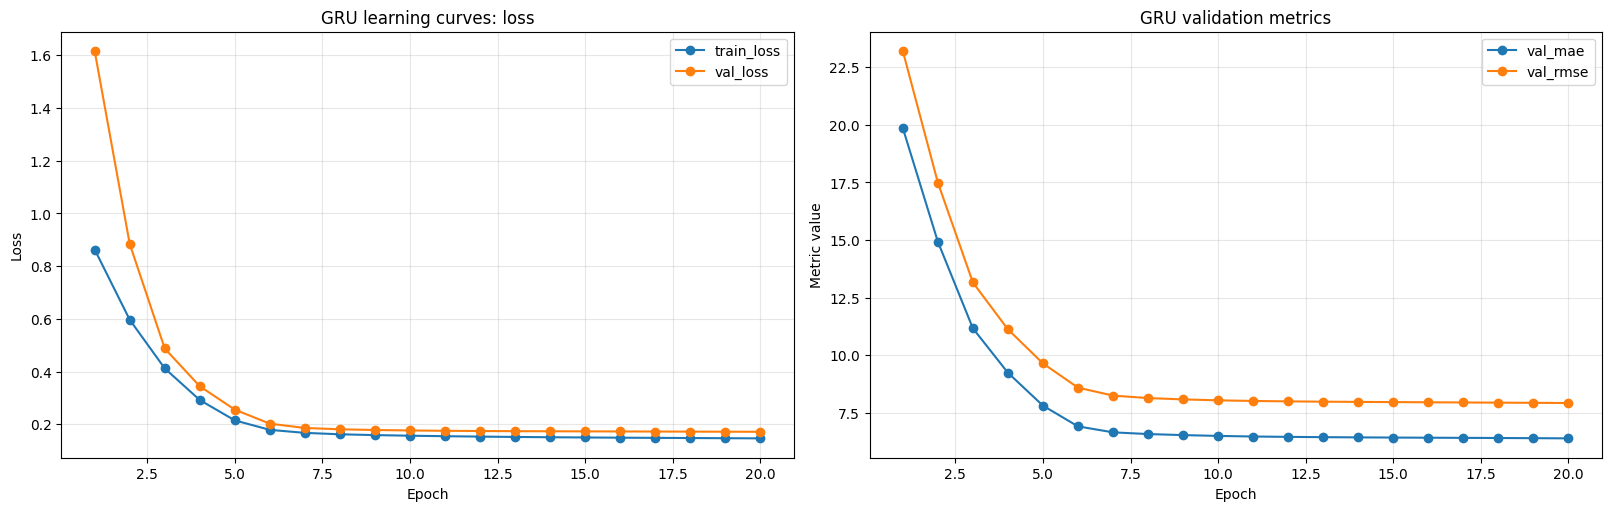

Saved: ./artifacts/figures/gru_learning_curves.png


In [17]:
history_df = pd.DataFrame(gru_history)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
axes[0].set_title("GRU learning curves: loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_mae"], marker="o", label="val_mae")
axes[1].plot(history_df["epoch"], history_df["val_rmse"], marker="o", label="val_rmse")
axes[1].set_title("GRU validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric value")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.savefig(GRU_CURVES_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["gru_learning_curves_png"])

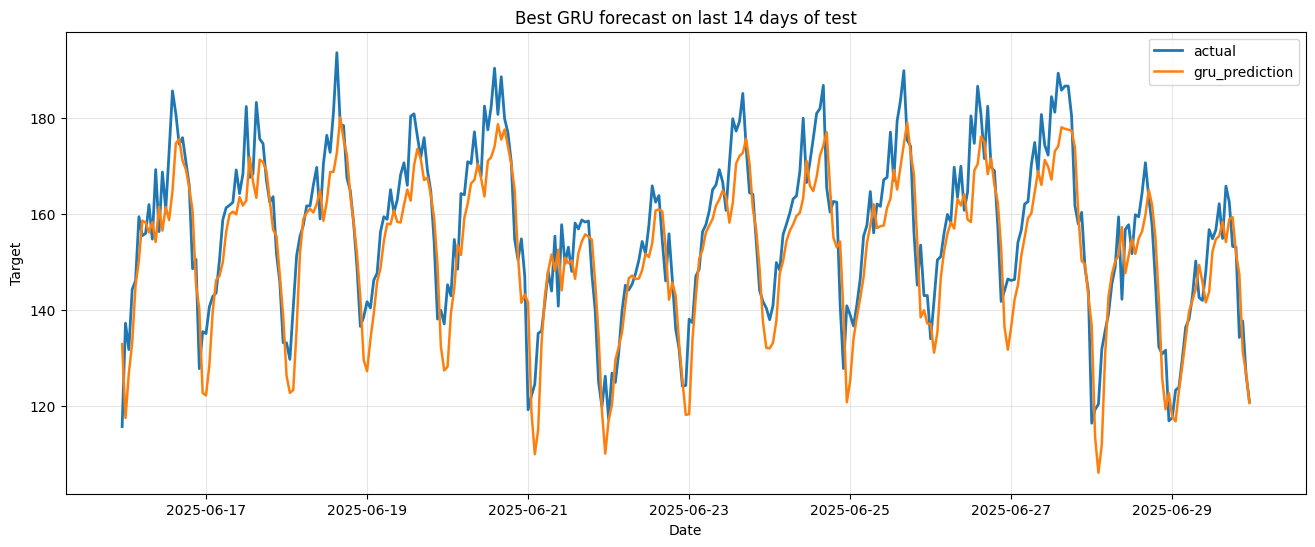

Saved: ./artifacts/figures/best_forecast_test.png


In [18]:
gru_test_plot_df = pd.DataFrame(
    {
        "date": pd.to_datetime(test_seq_dates),
        "actual": gru_test_eval["targets"],
        "prediction": gru_test_eval["predictions"],
    }
)

plot_cutoff = gru_test_plot_df["date"].max() - pd.Timedelta(days=14)
gru_test_plot_tail = gru_test_plot_df.loc[gru_test_plot_df["date"] >= plot_cutoff].copy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(gru_test_plot_tail["date"], gru_test_plot_tail["actual"], linewidth=2.0, label="actual")
ax.plot(gru_test_plot_tail["date"], gru_test_plot_tail["prediction"], linewidth=1.8, label="gru_prediction")

ax.set_title("Best GRU forecast on last 14 days of test")
ax.set_xlabel("Date")
ax.set_ylabel("Target")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(BEST_FORECAST_TEST_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["best_forecast_test_png"])

In [19]:
runs_df = pd.DataFrame(results_rows)

runs_df["experiment_id"] = runs_df["run_name"]
runs_df["task"] = TASK_NAME
runs_df["dataset"] = DATASET_NAME
runs_df["seed"] = SEED
runs_df["split_summary"] = json.dumps(SPLIT_SUMMARY_STRUCT, ensure_ascii=False)
runs_df["horizon"] = HORIZON

model_summary_map = {
    "B1_naive_last": "B1 naive-last forecast: y_hat(t)=y(t-1)",
    "B2_moving_average_24": "B2 moving-average forecast over previous 24 hours",
    "B3_ridge_lag_features": f"B3 Ridge regression on engineered lag/rolling/calendar features; alpha={best_ridge_alpha}",
    "R1_gru_forecast": (
        f"R1 GRUForecast(input_size={GRU_CONFIG['input_size']}, "
        f"hidden_size={GRU_CONFIG['hidden_size']}, num_layers={GRU_CONFIG['num_layers']}, "
        f"dropout={GRU_CONFIG['dropout']})"
    ),
}

features_summary_map = {
    "B1_naive_last": "previous value only: lag_1",
    "B2_moving_average_24": "rolling mean over previous 24 hours",
    "B3_ridge_lag_features": FEATURES_SUMMARY_TEXT,
    "R1_gru_forecast": f"raw target history window of length {GRU_CONFIG['window_size']}",
}

scaler_map = {
    "B1_naive_last": "none",
    "B2_moving_average_24": "none",
    "B3_ridge_lag_features": "StandardScaler(train_only_fit_then_val_test_transform)",
    "R1_gru_forecast": "zscore_train_only_on_target",
}

optimizer_map = {
    "B1_naive_last": "not_applicable",
    "B2_moving_average_24": "not_applicable",
    "B3_ridge_lag_features": "not_applicable",
    "R1_gru_forecast": "Adam",
}

lr_map = {
    "B1_naive_last": None,
    "B2_moving_average_24": None,
    "B3_ridge_lag_features": None,
    "R1_gru_forecast": GRU_CONFIG["learning_rate"],
}

epochs_trained_map = {
    "B1_naive_last": 0,
    "B2_moving_average_24": 0,
    "B3_ridge_lag_features": 1,
    "R1_gru_forecast": int(len(gru_history["epoch"])),
}

notes_map = {
    "B1_naive_last": "Temporal baseline B1.",
    "B2_moving_average_24": "Temporal baseline B2.",
    "B3_ridge_lag_features": "Temporal baseline B3 with lag/rolling/calendar features and explicit scaler fit/transform on train only.",
    "R1_gru_forecast": "R1 GRU trained on temporal windows; best model selected by validation MAE.",
}

runs_df["model_summary"] = runs_df["run_name"].map(model_summary_map)
runs_df["features_summary"] = runs_df["run_name"].map(features_summary_map)
runs_df["scaler"] = runs_df["run_name"].map(scaler_map)
runs_df["optimizer"] = runs_df["run_name"].map(optimizer_map)
runs_df["lr"] = runs_df["run_name"].map(lr_map)
runs_df["epochs_trained"] = runs_df["run_name"].map(epochs_trained_map)

runs_df["best_val_mae"] = runs_df["val_mae"]
runs_df["best_val_rmse"] = runs_df["val_rmse"]
runs_df["best_val_mape"] = runs_df["val_mape"]
runs_df["notes"] = runs_df["run_name"].map(notes_map)

preferred_order = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "split_summary",
    "horizon",
    "run_name",
    "model_family",
    "model_summary",
    "features_summary",
    "scaler",
    "optimizer",
    "lr",
    "window_size",
    "alpha",
    "hidden_size",
    "num_layers",
    "dropout",
    "batch_size",
    "max_epochs",
    "epochs_trained",
    "learning_rate",
    "val_mae",
    "val_rmse",
    "val_mape",
    "best_val_mae",
    "best_val_rmse",
    "best_val_mape",
    "test_mae",
    "test_rmse",
    "test_mape",
    "notes",
]

runs_df = runs_df[preferred_order]
runs_df = runs_df.sort_values(["best_val_mae", "test_mae"], ascending=[True, True]).reset_index(drop=True)
runs_df.to_csv(RUNS_CSV_PATH, index=False)

display(runs_df)
print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["runs_csv"])

,experiment_id,task,dataset,seed,split_summary,horizon,run_name,model_family,model_summary,features_summary,...,val_mae,val_rmse,val_mape,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B3_ridge_lag_features,time_series_forecasting,S12-hw-dataset.csv,42,"{""strategy"": ""temporal_split"", ""train_fraction...",1,B3_ridge_lag_features,ridge_tabular,B3 Ridge regression on engineered lag/rolling/...,"lags=[1,2,3,7,14,24,25,48,72,168]; rolling=[me...",...,4.082913,5.299520,2.737703,4.082913,5.299520,2.737703,3.856056,5.102185,2.497060,Temporal baseline B3 with lag/rolling/calendar...
1,R1_gru_forecast,time_series_forecasting,S12-hw-dataset.csv,42,"{""strategy"": ""temporal_split"", ""train_fraction...",1,R1_gru_forecast,gru,"R1 GRUForecast(input_size=1, hidden_size=32, n...",raw target history window of length 168,...,6.386081,7.921052,4.290214,6.386081,7.921052,4.290214,6.584397,8.417595,4.249740,R1 GRU trained on temporal windows; best model...
2,B1_naive_last,time_series_forecasting,S12-hw-dataset.csv,42,"{""strategy"": ""temporal_split"", ""train_fraction...",1,B1_naive_last,baseline,B1 naive-last forecast: y_hat(t)=y(t-1),previous value only: lag_1,...,6.444815,8.201023,4.397922,6.444815,8.201023,4.397922,6.342438,8.059069,4.148548,Temporal baseline B1.
3,B2_moving_average_24,time_series_forecasting,S12-hw-dataset.csv,42,"{""strategy"": ""temporal_split"", ""train_fraction...",1,B2_moving_average_24,baseline,B2 moving-average forecast over previous 24 hours,rolling mean over previous 24 hours,...,13.397980,16.169904,9.198834,13.397980,16.169904,9.198834,13.140498,16.110844,8.738701,Temporal baseline B2.


Saved: ./artifacts/runs.csv


In [20]:
best_gru_config_payload = {
    "experiment_id": GRU_CONFIG["experiment_id"],
    "task": GRU_CONFIG["task"],
    "dataset": GRU_CONFIG["dataset"],
    "seed": GRU_CONFIG["seed"],
    "target_column": GRU_CONFIG["target_column"],
    "frequency": GRU_CONFIG["frequency"],
    "horizon": GRU_CONFIG["horizon"],
    "window_size": GRU_CONFIG["window_size"],
    "split_summary": SPLIT_SUMMARY_STRUCT,
    "architecture": GRU_CONFIG["architecture"],
    "training_hyperparameters": GRU_CONFIG["training_hyperparameters"],
    "scaler": GRU_CONFIG["scaler"],
    "best_epoch": int(best_epoch),
    "epochs_trained": int(len(gru_history["epoch"])),
    "best_val_mae": float(gru_val_eval["mae"]),
    "best_val_rmse": float(gru_val_eval["rmse"]),
    "best_val_mape": float(gru_val_eval["mape"]),
    "test_mae": float(gru_test_eval["mae"]),
    "test_rmse": float(gru_test_eval["rmse"]),
    "test_mape": float(gru_test_eval["mape"]),
    "notes": "Temporal split only; model selected by validation MAE; scaler fit on train only.",
}

torch.save(
    {
        "model_state_dict": gru_model.state_dict(),
        "config": best_gru_config_payload,
    },
    BEST_GRU_PATH,
)

with open(BEST_GRU_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_gru_config_payload, f, ensure_ascii=False, indent=2)

print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["best_gru_pt"])
print("Saved:", NOTEBOOK_RELATIVE_ARTIFACT_PATHS["best_gru_config_json"])

Saved: ./artifacts/best_gru.pt
Saved: ./artifacts/best_gru_config.json


In [21]:
artifact_check = pd.DataFrame(
    [
        {"artifact": "./artifacts/runs.csv", "exists": RUNS_CSV_PATH.exists()},
        {"artifact": "./artifacts/best_gru.pt", "exists": BEST_GRU_PATH.exists()},
        {"artifact": "./artifacts/best_gru_config.json", "exists": BEST_GRU_CONFIG_PATH.exists()},
        {"artifact": "./artifacts/figures/series_split.png", "exists": SERIES_SPLIT_FIG_PATH.exists()},
        {"artifact": "./artifacts/figures/baselines_compare.png", "exists": BASELINES_COMPARE_FIG_PATH.exists()},
        {"artifact": "./artifacts/figures/gru_learning_curves.png", "exists": GRU_CURVES_FIG_PATH.exists()},
        {"artifact": "./artifacts/figures/best_forecast_test.png", "exists": BEST_FORECAST_TEST_FIG_PATH.exists()},
    ]
)

display(artifact_check)

,artifact,exists
0,./artifacts/runs.csv,True
1,./artifacts/best_gru.pt,True
2,./artifacts/best_gru_config.json,True
3,./artifacts/figures/series_split.png,True
4,./artifacts/figures/baselines_compare.png,True
5,./artifacts/figures/gru_learning_curves.png,True
6,./artifacts/figures/best_forecast_test.png,True


In [22]:
best_row = runs_df.iloc[0].to_dict()

print("Best run by validation MAE:")
for k, v in best_row.items():
    print(f"{k}: {v}")

Best run by validation MAE:
experiment_id: B3_ridge_lag_features
task: time_series_forecasting
dataset: S12-hw-dataset.csv
seed: 42
split_summary: {"strategy": "temporal_split", "train_fraction": 0.7, "validation_fraction": 0.15, "test_fraction": 0.15, "train_start": "2025-01-01 00:00:00", "train_end": "2025-05-06 23:00:00", "validation_start": "2025-05-07 00:00:00", "validation_end": "2025-06-02 23:00:00", "test_start": "2025-06-03 00:00:00", "test_end": "2025-06-29 23:00:00", "random_split_used": false, "shuffle_used_for_temporal_folds": false, "reason_random_split_incorrect": "random split mixes past and future observations and can leak future information into training"}
horizon: 1
run_name: B3_ridge_lag_features
model_family: ridge_tabular
model_summary: B3 Ridge regression on engineered lag/rolling/calendar features; alpha=30.0
features_summary: lags=[1,2,3,7,14,24,25,48,72,168]; rolling=[mean,std,min,max] for windows [7,24,168]; calendar=[hour,day_of_week,day_of_month,month,is_we